# 01. Análise Exploratória de Dados (EDA) - Clima RS

Este notebook faz a exploração inicial dos dados sintéticos gerados para simular a climatologia e hidrologia do Rio Grande do Sul.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregando dados brutos do INMET e ANA

In [2]:
df_inmet = pd.read_csv('../data/raw/inmet.csv')
df_ana = pd.read_csv('../data/raw/ana.csv')

df_inmet['timestamp'] = pd.to_datetime(df_inmet['timestamp'])
df_ana['timestamp'] = pd.to_datetime(df_ana['timestamp'])

print("INMET shape:", df_inmet.shape)
print("ANA shape:", df_ana.shape)
print("Features INMET:", list(df_inmet.columns))
print("Features ANA:", list(df_ana.columns))

INMET shape: (56929, 6)
ANA shape: (56929, 3)
Features INMET: ['timestamp', 'precipitacao', 'velocidade_vento', 'temperatura', 'umidade', 'pressao']
Features ANA: ['timestamp', 'nivel_rio', 'vazao']


## 2. Mesclando as Bases

In [3]:
df = pd.merge(df_inmet, df_ana, on='timestamp', how='inner')
print("Merged shape:", df.shape)
df.head()

Merged shape: (56929, 8)


,timestamp,precipitacao,velocidade_vento,temperatura,umidade,pressao,nivel_rio,vazao
0,2018-01-01 00:00:00,0.0,9.10,21.6,72.3,1011.0,198.3,48.6
1,2018-01-01 01:00:00,0.0,5.88,19.3,80.9,1012.3,202.5,52.4
2,2018-01-01 02:00:00,0.0,18.32,21.1,71.3,1009.7,202.8,48.7
3,2018-01-01 03:00:00,0.0,8.62,21.3,75.7,1014.1,205.6,50.5
4,2018-01-01 04:00:00,0.0,3.49,20.0,79.2,1008.8,198.6,51.3


## 3. Estatísticas Descritivas

In [4]:
df.describe()

,timestamp,precipitacao,velocidade_vento,temperatura,umidade,pressao,nivel_rio,vazao
count,56929,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000,56929.000000
mean,2021-04-01 00:00:00,0.435771,9.286948,18.131945,75.191217,1010.958912,348.250489,398.538035
min,2018-01-01 00:00:00,0.000000,3.000000,-1.100000,47.900000,971.000000,193.200000,45.400000
25%,2019-08-17 00:00:00,0.000000,4.740000,12.900000,70.400000,1009.000000,250.000000,110.300000
50%,2021-04-01 00:00:00,0.000000,7.220000,18.200000,75.100000,1011.100000,309.400000,211.100000
75%,2022-11-15 00:00:00,0.000000,11.560000,23.300000,79.700000,1013.200000,389.800000,388.200000
max,2024-06-30 00:00:00,82.640000,80.310000,38.100000,100.000000,1024.400000,2428.900000,15714.800000
std,NaN,2.361735,6.648075,6.946241,6.794182,3.853198,194.199479,1104.224323


## 4. Visualizando Padrões Sazonais e Diários

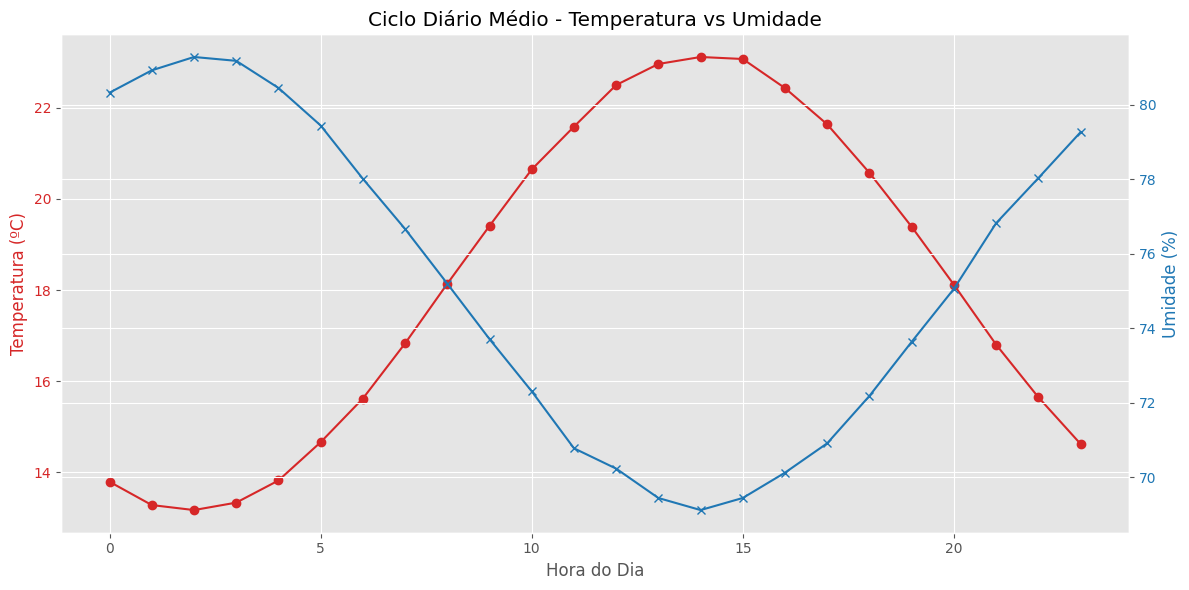

In [5]:
# Ciclo de 24 horas - Temperatura vs Umidade
df['hour'] = df['timestamp'].dt.hour
hourly_stats = df.groupby('hour')[['temperatura', 'umidade']].mean()

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Hora do Dia')
ax1.set_ylabel('Temperatura (ºC)', color=color)
ax1.plot(hourly_stats.index, hourly_stats['temperatura'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Umidade (%)', color=color)
ax2.plot(hourly_stats.index, hourly_stats['umidade'], color=color, marker='x')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ciclo Diário Médio - Temperatura vs Umidade')
fig.tight_layout()
plt.show()

## 5. Matriz de Correlação das Variáveis

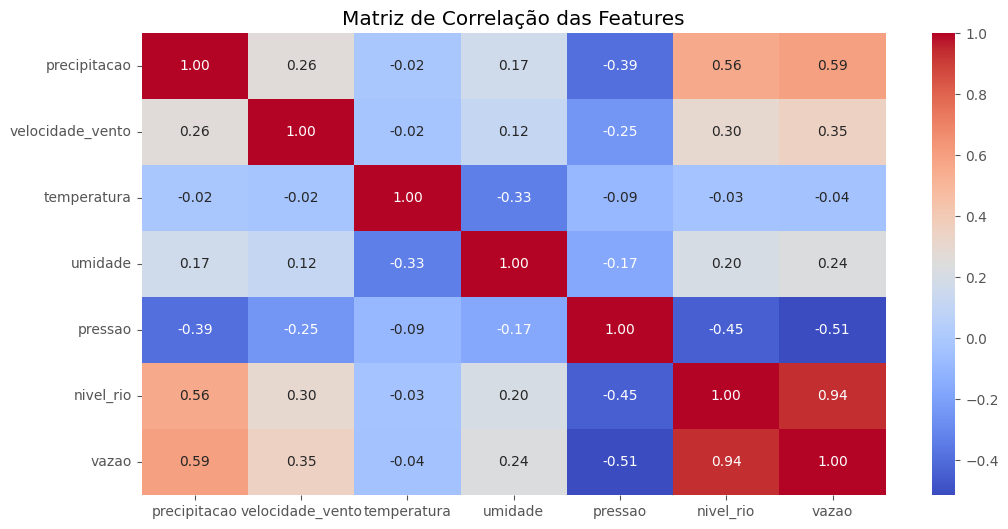

In [6]:
corr = df.drop(columns=['timestamp', 'hour']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Features')
plt.show()

## 6. Identificando Picos Históricos de Nível do Rio

In [7]:
top_levels = df.sort_values(by='nivel_rio', ascending=False).head(10)
print("Top 10 Maiores Níveis Registrados:")
print(top_levels[['timestamp', 'nivel_rio', 'precipitacao', 'vazao']])

Top 10 Maiores Níveis Registrados:
                timestamp  nivel_rio  precipitacao    vazao
55605 2024-05-05 21:00:00     2428.9         27.25  15714.8
55603 2024-05-05 19:00:00     2426.3         42.14  15697.3
55604 2024-05-05 20:00:00     2423.9         13.32  15622.9
55606 2024-05-05 22:00:00     2423.2         13.27  15638.6
55610 2024-05-06 02:00:00     2414.6         14.79  15519.9
55608 2024-05-06 00:00:00     2414.0         27.62  15622.1
55609 2024-05-06 01:00:00     2413.1         15.67  15577.1
55607 2024-05-05 23:00:00     2411.9          9.52  15522.6
55597 2024-05-05 13:00:00     2410.9         46.45  15550.4
55601 2024-05-05 17:00:00     2409.4         35.25  15515.6
